# House Price Prediction using Machine Learning

## Aim
To build a Machine Learning model for predicting house prices using Data Science techniques including:
- Data Cleaning
- Data Preprocessing
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Machine Learning Model Building
- Model Evaluation


## Dataset Information

Dataset Used:
Housing Price Dataset

Dataset Source:
https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv

This dataset contains:
- Crime Rate
- Number of Rooms
- Property Tax
- Accessibility
- Pollution Levels
- House Prices

Target Variable:
- medv → Median value of owner-occupied homes


## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load Dataset

In [2]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

house_df = pd.read_csv(url)

house_df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


## Dataset Information

In [3]:
house_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


### Observation
- Dataset contains numerical features.
- Suitable for regression analysis and price prediction.

## Check Missing Values

In [4]:
house_df.isnull().sum()

,0
crim,0
zn,0
indus,0
chas,0
nox,0
rm,0
age,0
dis,0
rad,0
tax,0


## Check Duplicate Values

In [5]:
house_df.duplicated().sum()

np.int64(0)

## Remove Duplicate Values

In [6]:
house_df = house_df.drop_duplicates()

## Statistical Summary

In [7]:
house_df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


# Exploratory Data Analysis (EDA)

## Correlation Matrix

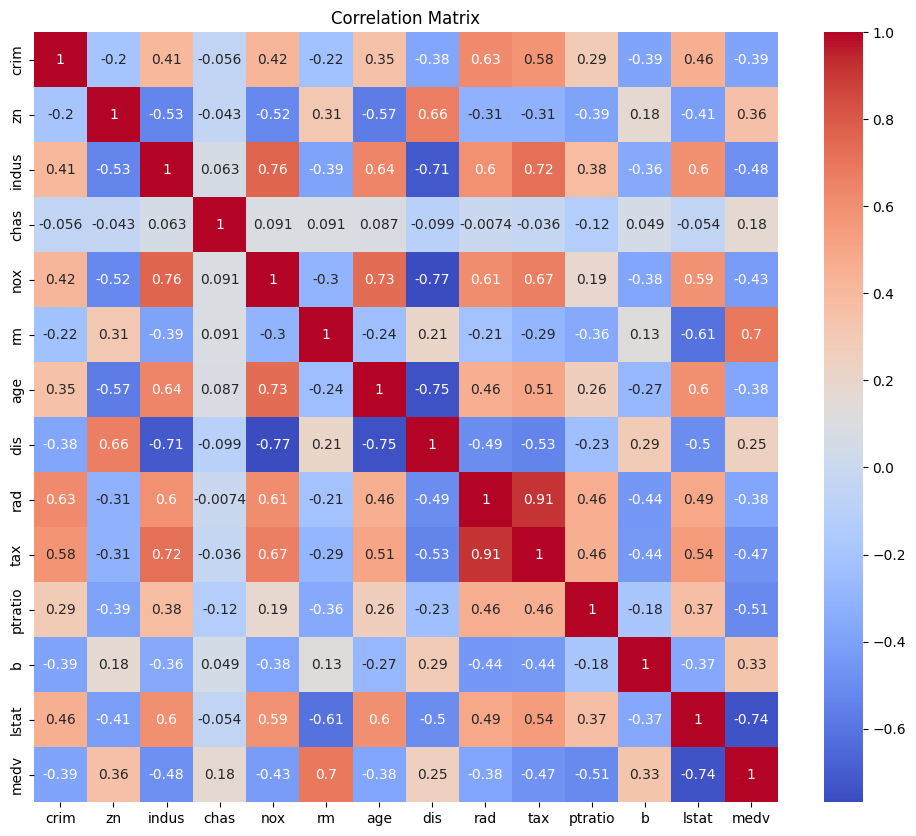

In [8]:
plt.figure(figsize=(12,10))

sns.heatmap(house_df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()

### Observation
- RM has strong positive correlation with house prices.
- LSTAT has strong negative correlation with house prices.

## Distribution of House Prices

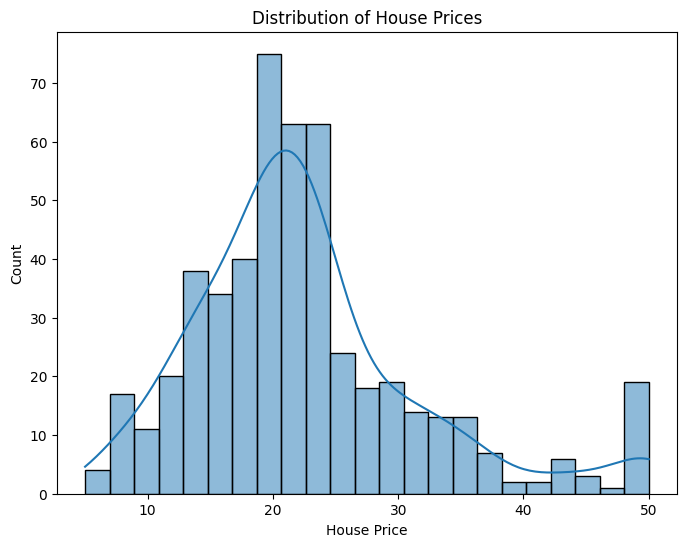

In [9]:
plt.figure(figsize=(8,6))

sns.histplot(house_df['medv'], kde=True)

plt.title('Distribution of House Prices')
plt.xlabel('House Price')

plt.show()

## Average Rooms vs House Price

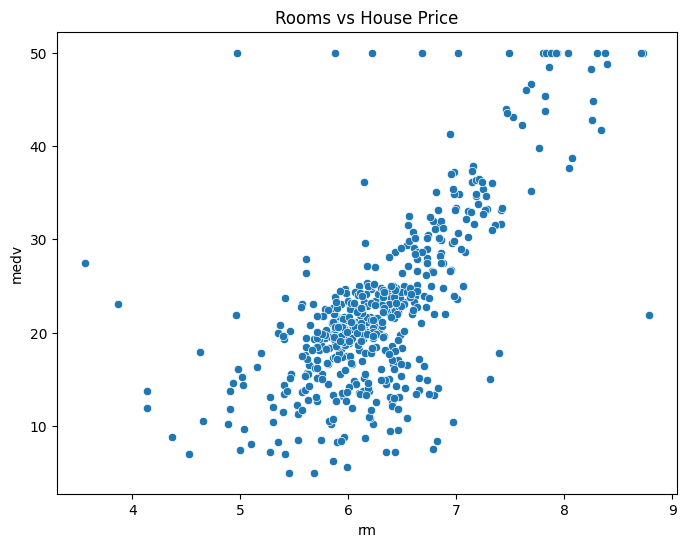

In [10]:
plt.figure(figsize=(8,6))

sns.scatterplot(x='rm', y='medv', data=house_df)

plt.title('Rooms vs House Price')

plt.show()

## Crime Rate vs House Price

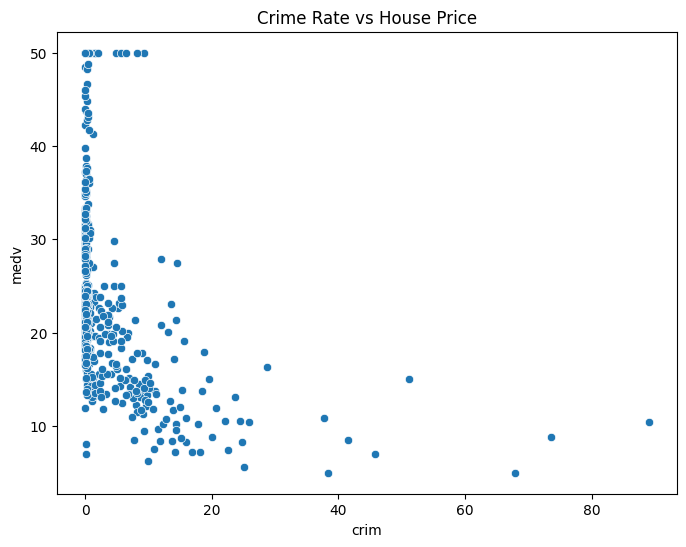

In [11]:
plt.figure(figsize=(8,6))

sns.scatterplot(x='crim', y='medv', data=house_df)

plt.title('Crime Rate vs House Price')

plt.show()

## Pairplot

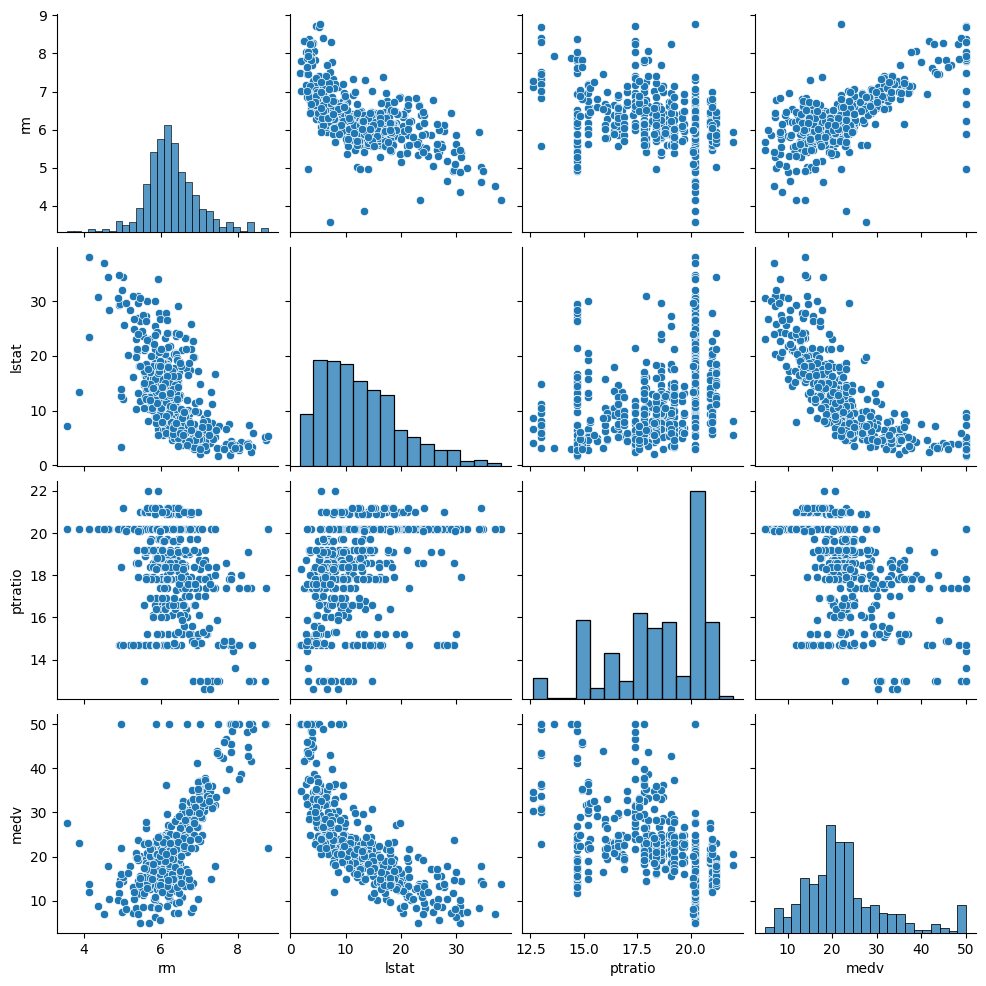

In [12]:
sns.pairplot(house_df[['rm', 'lstat', 'ptratio', 'medv']])

plt.show()

# Business Insights

### Key Insights
- Houses with more rooms generally have higher prices.
- High crime rate areas have lower property prices.
- Lower income areas tend to have lower house values.
- Property tax and pollution also affect prices.


# Machine Learning - House Price Prediction

## Prepare Features and Target

In [13]:
X = house_df.drop('medv', axis=1)
y = house_df['medv']

## Split Dataset

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Train Linear Regression Model

In [15]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

LinearRegression()

## Train Random Forest Regressor

In [16]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

## Predict Test Data

In [17]:
lr_pred = lr_model.predict(X_test)

rf_pred = rf_model.predict(X_test)

## Compare Actual and Predicted Values

In [18]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Linear Regression Prediction': lr_pred,
    'Random Forest Prediction': rf_pred
})

comparison.head()

,Actual Price,Linear Regression Prediction,Random Forest Prediction
0,23.6,28.996724,22.839
1,32.4,36.025565,30.676
2,13.6,14.816944,16.317
3,22.8,25.031979,23.510
4,16.1,18.769880,16.819


## Model Evaluation - Linear Regression

In [19]:
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print('Linear Regression MAE:', lr_mae)
print('Linear Regression RMSE:', lr_rmse)
print('Linear Regression R2 Score:', lr_r2)

Linear Regression MAE: 3.189091965887837
Linear Regression RMSE: 4.928602182665332
Linear Regression R2 Score: 0.6687594935356326


## Model Evaluation - Random Forest

In [20]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print('Random Forest MAE:', rf_mae)
print('Random Forest RMSE:', rf_rmse)
print('Random Forest R2 Score:', rf_r2)

Random Forest MAE: 2.0395392156862746
Random Forest RMSE: 2.8109631609391226
Random Forest R2 Score: 0.8922527442109116


### Observation
- Lower MAE and RMSE indicate better prediction performance.
- Higher R2 score indicates better model accuracy.

## Actual vs Predicted Graph

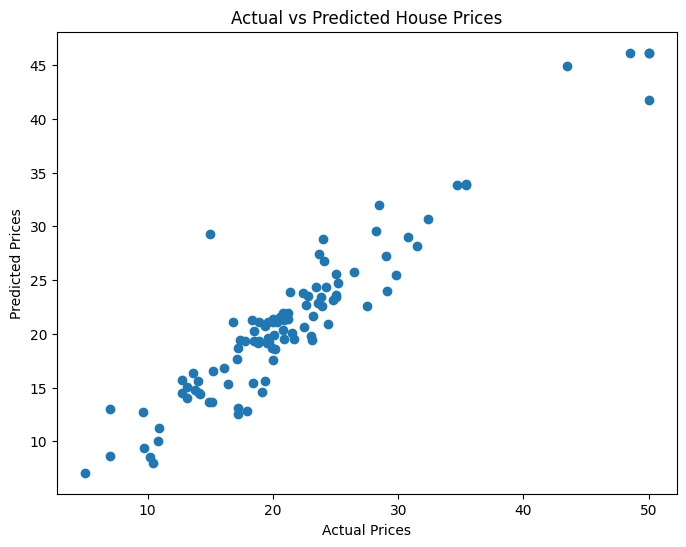

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_pred)

plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')

plt.title('Actual vs Predicted House Prices')

plt.show()

## Feature Importance

In [22]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

importance.head(10)

,Feature,Importance
5,rm,0.503845
12,lstat,0.309509
7,dis,0.060549
0,crim,0.038062
10,ptratio,0.016313
9,tax,0.015661
4,nox,0.015544
6,age,0.013840
11,b,0.012154
2,indus,0.007953


## Predict New House Price

In [24]:
sample_house = pd.DataFrame({
    'crim': [0.1],
    'zn': [18.0],
    'indus': [2.31],
    'chas': [0],
    'nox': [0.538],
    'rm': [6.575],
    'age': [65.2],
    'dis': [4.09],
    'rad': [1],
    'tax': [296],
    'ptratio': [15.3],
    'b': [396.9],
    'lstat': [4.98]
})

predicted_price = rf_model.predict(sample_house)

print('Predicted House Price:', predicted_price[0])

Predicted House Price: 28.81599999999999


# Conclusion
- Housing data was successfully analyzed.
- EDA and visualization techniques were applied.
- Machine Learning models successfully predicted house prices.
- Random Forest performed better than Linear Regression.
- Number of rooms and lower crime rates positively impacted house prices.
